------------------------------------------------------

<font size= 6 color='k'>
<b>Tarea 1. Osciladores</b>
</font>
<br>


---------------------------------------------------------

In [ ]:
# SurfacePlot3D.py
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

X, Y = np.meshgrid(np.arange(-100, 100), np.arange(-100,100))
Z = X ** 2 + Y ** 2

G_x2, G_y2 = np.gradient(Z)
G = np.sqrt(G_x2 + G_y2)
G = G / G.max()

#Figure contains all of the objects in the plot
fig = plt.figure()
#Get the axes of the plot
ax = Axes3D(fig)
#THIS DOESN'T WORK IN VS Code, but works in Spyder
#Uncomment the following line to plot the surface.
ax.plot_surface(X,Y,Z, facecolors=cm.inferno(G))
#Show the Plot
plt.show()

<font size= 5 color='k' >
<b>Analysis of the behavior of a 1D nonlinear oscillator and the electrical oscillations in a Josephson junction.</b>
</font>


Dayana Andrea Henao Arbeláez
Yuliana Guerrero Uchima

--------------------------------------------------------
Problem Statement

---------------------------------------------------------------

Con el presente trabajo, se busca comprender y analizar las similitudes y diferencias entre dos fenómenos físicos: las oscilaciones en un oscilador 1D no lineal y las oscilaciones eléctricas en una juntura Josephson.


--------------------------------------------------------

<font size=5 color='k' >
<b>Teory</b>
</font>

--------------------------------------------------------



<font size=4 color='K' >
<b>Josephson,s juntions</b>
</font>




983
A Josephson junction is an electronic device that exhibits quantum behavior in the realm of superconductivity, allowing the flow of electric current without resistance through a thin barrier between two superconductors, characterized by the wave functions $\Psi_{1}e^{i\phi_{1}}$ and $\Psi_{2}e^{i\phi_{2}}$ respectively, even when no potential difference is applied between them.

This device was developed following the discovery of the Josephson Effect, which occurs due to the quantum tunneling of Cooper pairs across the junction between the two superconductors.

According to BCS theory, electric current in superconductors is not carried by individual electrons, as would be the case in a normal conductor, but rather by electrons pairing up to form Cooper pairs. These electron pairs move through the superconductor without dissipating energy due to the lack of electrical resistance [1].

This behavior, although classically impossible, presents some similarities with a classical dynamic system, the 1D nonlinear oscillator [2].








One of the basic equations governing the dynamics of the Josephson effect is:

$$ \tag{1}
I(t)=I_cSin(\phi(t))
$$

where $I(t)$ is the current through the junction, $\phi(t) = \phi_{1}(t)-\phi_{2}(t)$ is the phase difference between the wave functions in the two superconductors, and $I_{c}$ is the critical junction current, which is the maximum current that can flow through the junction and can be altered by both temperature and an applied magnetic field. The physical constant,
$\frac {\hbar}{2e}$, is the quantum of magnetic flux [1].



This relationship applies only to the electron pair current, implying that $\phi$ increases as the external current $I$ increases. If the value of $I$ is greater than the critical current $I_c$, the phase difference cannot be kept constant, and a voltage is generated across the junction. The rate of phase change and this voltage are related as follows:

$$
U(t)=\frac{ \hbar}{2e}\frac{\partial \phi}{\partial t}
$$

In general, the current passing through this junction has components of a displacement current, represented by a capacitor, and an ordinary current, represented by a resistor, resulting in the equivalent circuit shown in Figure 2 [3].

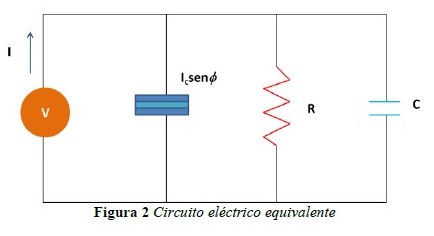


Applying Kirchhoff's laws to the circuit, we have:
$$
I=\frac{U}{R} + I_c sin\phi + C \dot{U}
$$ Rewriting in terms of the phase difference $\phi$:





$$ \tag{2}
\frac{\hbar C}{2eI_c}\ddot{\phi} + \frac{\hbar}{2eRI_c}\dot{\phi}+ \sin{\phi}  =\frac{I}{I_c}
$$

**Typical Parameter Values**

The critical current range is $Ic \in [1 µA - 1 mA]$, and the typical voltage is $I_cR \approx 1 mV$. Since $\frac {\hbar}{2e} \approx 4.38 * 10^4$ Hz/V, the typical frequency is on the order of $10^{11}$ Hz. Finally, the typical scale length for the Josephson junction is approximately $1$ m, but this depends on the geometry and type of coupling used [2].

<font size=4 color='K' >
<b>Oscilador 1D no lineal</b>
</font>

It is a physical system that exhibits oscillations or vibrations in a single spatial dimension. This work will analyze the behavior of a simple pendulum and a forced damped pendulum.

### Péndulo Simple

The equation of motion is:

$$ \tag{3}
\ddot{\theta} + \frac{g}{l} \sin \theta=0
$$

where $l$ is the length of the pendulum, $g$ is the acceleration due to gravity, and $\theta$ is its angular displacement [4].






### Péndulo Amortiguado Forzado


The motion equation is :

$$ \tag{4}
\ddot\theta+2\lambda\dot\theta+\frac{g}{l}sin(\theta)=\Gamma
$$
where $\lambda$ is the damping parameter and $\Gamma$ is a constant external force [4].



In the case of a pendulum, the natural frequency of oscillation is:

$w_{o}^2 = \frac{g}{l}$

In the case of a Josephson junction, the frequency of oscillation is:

$w_{o}^2 = \frac{2e}{\hbar} \frac{I_c}{2I}$

This frequency is known as the Josephson frequency.

<font size=5 color='k' >
<b>Solution</b>
</font>

# Numerical Solution of Differential Equations

All the differential equations discussed here are solved numerically using the `odeint` method from `scipy.integrate`. 

To solve them, we express the equations in state-space representation (matrix form), defining the state vector $U$ in the phase space $\{\theta, \dot{\theta}\}$ as follows:

$$
U = \begin{bmatrix} X[0] \\ X[1] \end{bmatrix} = \begin{bmatrix} \theta \\ \dot{\theta} \end{bmatrix}
$$

---

## Equations of Motion

The dynamics for each system are described by the derivative vector $\frac{dU}{dt}$:

### 1. Simple Pendulum
The basic model for a non-linear pendulum without friction or external forces:
$$
\frac{dU}{dt} = \begin{bmatrix}
       X[1] \\
       -\omega_0^2\sin{X[0]}
     \end{bmatrix}
$$

### 2. Damped Driven Pendulum
A pendulum that includes a damping coefficient $\lambda$ and an external driving force $\Gamma$:
$$
\frac{dU}{dt} = \begin{bmatrix}
       X[1] \\
       \Gamma-\omega_0^2\sin{X[0]}-2\lambda X[1]
     \end{bmatrix}
$$

### 3. Josephson Junction
The model representing a superconducting Josephson junction, where $I$ is the bias current, $I_c$ the critical current, $R$ the resistance, and $C$ the capacitance:
$$
\frac{dU}{dt} = \begin{bmatrix}
       X[1] \\
       \left( \frac{I}{I_c} - \sin(X[0]) - \frac{\hbar}{2eRI_c}X[1] \right) \frac{2eI_c}{\hbar C}
     \end{bmatrix}
$$

In [ ]:
#@title Librerías
import numpy as np
from scipy.integrate import odeint
import matplotlib.pylab as plt
import matplotlib.pyplot as plt
from numpy.linalg import *
import scipy.integrate as integrate
from scipy import misc
import matplotlib.animation as animation
from matplotlib.patches import Circle, Wedge, Polygon


<font size=5 color='K' >
<b>El péndulo simple</b>
</font>

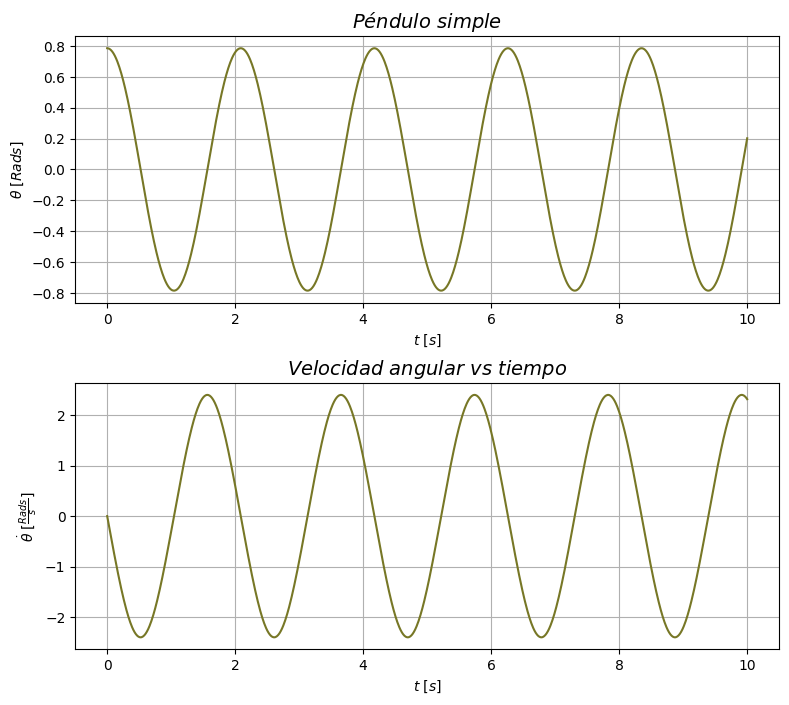

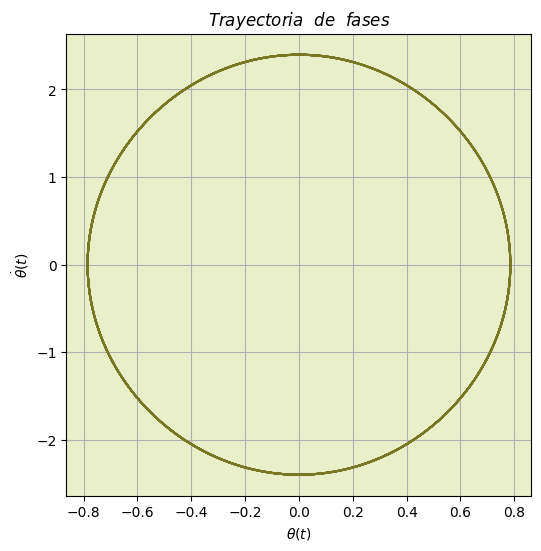

In [ ]:
#@title Solución a la ecuación de movimiento del péndulo simple
def dU1_dt(U, t,l=1,g=9.8):
    '''
    Here U is a vector such that   θ=U[0] and ω=U[1].
    This function should return [θ', ω']
    '''
    θ,ω=U
    return [ω, -g/l*np.sin( θ ) ]


def dU2_dt(U, t,m,Ic):
    '''
    Here U is a vector such that   θ=U[0] and ω=U[1].
    This function should return [θ', ω']
    '''
    θ,ω=U
    a=4.83e10
    #Ic=1#corriente critica
    I=1#corriente externa

    C=a*m
    #return [ω, -(a*Ic/(2*I))*np.sin( θ ) ]
    return [ω, -(a*Ic/(C))*np.sin( θ ) ]


U0=np.radians([45,0])  # theta, w
t=np.linspace(0,10,1000)
solucion1= odeint(dU1_dt, U0, t)


plt.subplot(3,1,1)
plt.subplots_adjust(bottom=.1,top=2.1,left=0.1,right=1.2,hspace=.3)

plt.plot(t,solucion1[:,0],'-',color='#777726')
plt.title(r'$\theta \,\,[Rads]$');
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\theta \,\,[Rads]$');
plt.title('$Péndulo \,\,simple$',size=14);
#plt.ylim(bottom=1)
plt.grid();

#-----------------dTheta_dt vs t-----------------------------------------
plt.subplot(3,1,2)

plt.plot(t,solucion1[:,1],'-',color='#777726')
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\dot{\theta} \,\,[\frac{Rads}{s}]$');
plt.title('$Velocidad \,\,angular\,\, vs\,\,tiempo$',size=14);
plt.grid();

# Trayectoria de fases
#figure, ax = plt.subplots()
figure, axes  =  plt.subplots(nrows = 1, ncols = 1,figsize = (6,6))  # big fig
figure.set_facecolor("#e9f0c9")
figure.patch.set_alpha(0.0)
axes.set_facecolor("#e9f0c9")


## axes.plot(U[1],U[2],'.')
axes.plot(solucion1[:,0],solucion1[:,1],color='#777726')
axes.grid()
axes.set_title(r'$Trayectoria {\ \ }de{\ \ }fases$')
axes.set_xlabel(r'$\theta(t)$')
axes.set_ylabel(r'$\dot{\theta}(t)$')

plt.show()

--------------------------------------------------------

<font size=5 color='K' >
<b>El péndulo amortiguado forzado</b>
</font>

--------------------------------------------------------

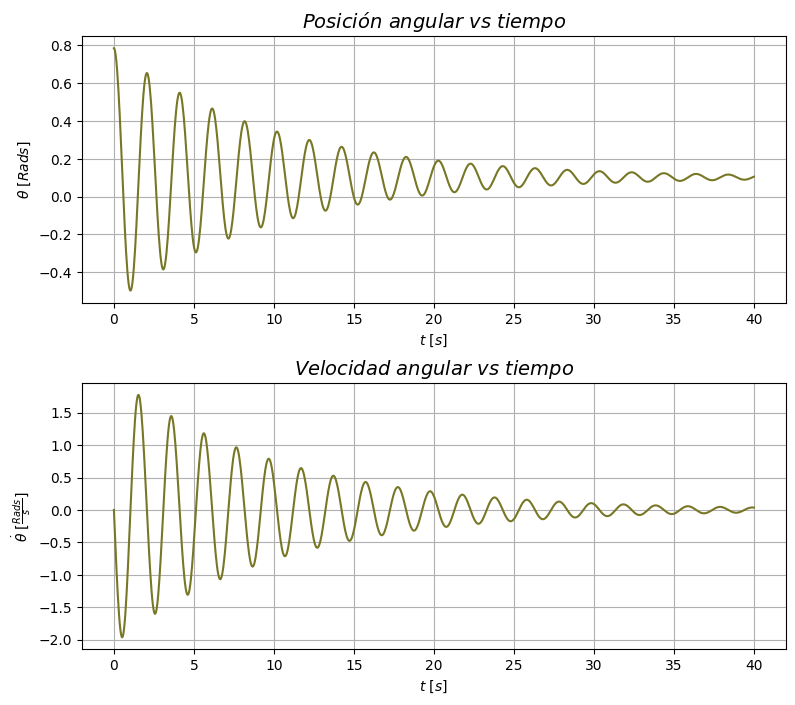

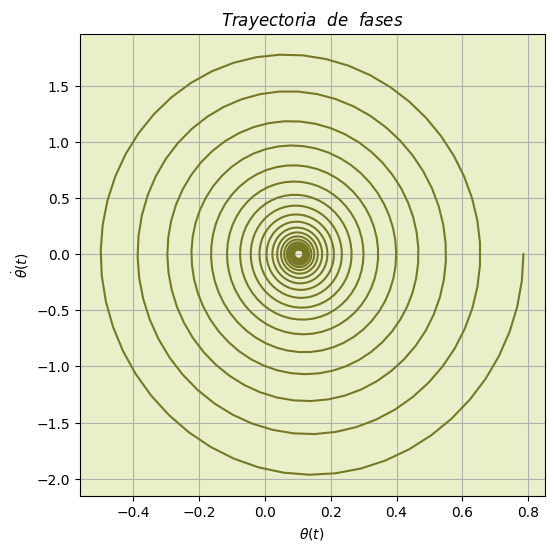

In [ ]:
#@title Solución de la ecuación diferencial del péndulo amortiguado

def dX_dt(X, t,n,m):
    g = 9.8
    l = 1.0
    m = 1.0
    lam=0.1
    w1 = X[1]
    dw1dt = 1-2*lam*X[1]-(g/l)*np.sin(X[0])

    return[w1,dw1dt]

t = np.linspace(0,40, 1000)

#Condiciones iniciales
X0 = np.array(np.radians([45,0]))
m=0
n=5
from scipy.integrate import odeint
SOL=odeint(dX_dt,X0,t,args=(n,m))


plt.subplots_adjust(bottom=.1,top=2.1,left=0.1,right=1.2,hspace=.3)
#-----------------Theta vs t-----------------------------------------
plt.subplot(3,1,1)

plt.plot(t,SOL[:,0],'-',color='#777726')
plt.title(r'$\theta \,\,[Rads]$');
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\theta \,\,[Rads]$');
plt.title('$Posición \,\,angular \,\,vs\,\, tiempo$',size=14);
#plt.ylim(bottom=1)
plt.grid();

#-----------------dTheta_dt vs t-----------------------------------------
plt.subplot(3,1,2)

plt.plot(t,SOL[:,1],'-',color='#777726')
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\dot{\theta} \,\,[\frac{Rads}{s}]$');
plt.title('$Velocidad \,\,angular\,\, vs\,\,tiempo$',size=14);
plt.grid();

# Trayectoria de fases
#figure, ax = plt.subplots()
figure, axes  =  plt.subplots(nrows = 1, ncols = 1,figsize = (6,6))  # big fig
figure.set_facecolor("#e9f0c9")
figure.patch.set_alpha(0.0)
axes.set_facecolor("#e9f0c9")


## axes.plot(U[1],U[2],'.')
axes.plot(SOL[:,0],SOL[:,1],color='#777726')
axes.grid()
axes.set_title(r'$Trayectoria {\ \ }de{\ \ }fases$')
axes.set_xlabel(r'$\theta(t)$')
axes.set_ylabel(r'$\dot{\theta}(t)$')

plt.show()

--------------------------------------------------------

<font size=5 color='K' >
<b>Efecto Josephson</b>
</font>

--------------------------------------------------------

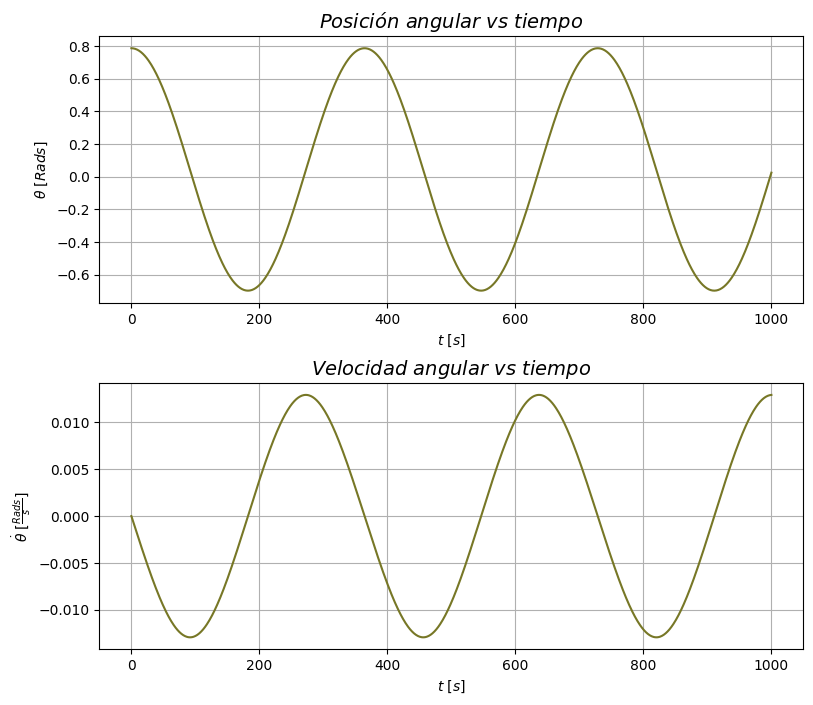

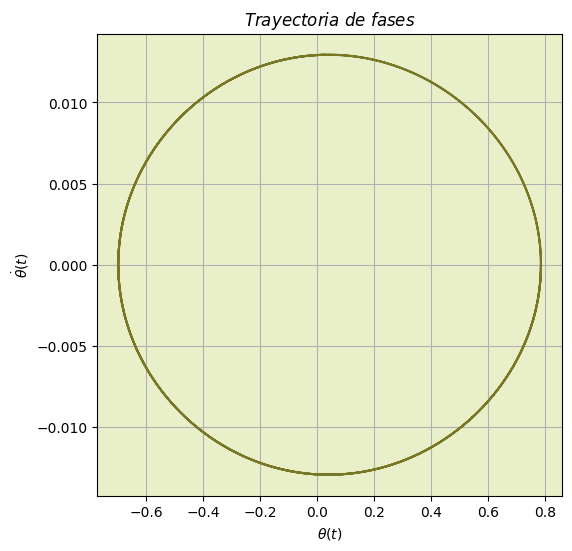

In [ ]:
#@title Solución de la ecuación diferencial que describe el efecto Josephson para $I<I_c$
# Sistema
def dU_dt(U,t,n,m,Ic):
  a=4.83e10
  I=1e-5 #corriente externa
  b=1e-3
  C=a*m
  return [U[1], (I/Ic -np.sin(U[0]) - U[1]/(a*b))*a*(Ic/C)]

IC=np.linspace(1e-6,1e-3,5)

U0 =np.radians( [45,0])
# Intervalo
m=U0[0]
ic=IC[1]
t = np.linspace(0,1000, 1000)
sol=odeint(dU_dt,U0,t,args=(n,m,ic))

plt.subplots_adjust(bottom=.1,top=2.1,left=0.1,right=1.2,hspace=.3)
#-----------------Theta vs t-----------------------------------------
plt.subplot(3,1,1)

plt.plot(t,sol[:,0],'-',color='#777726')
plt.title(r'$\theta \,\,[Rads]$');
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\theta \,\,[Rads]$');
plt.title('$Posición \,\,angular \,\,vs\,\, tiempo$',size=14);
plt.grid();

#-----------------dTheta_dt vs t-----------------------------------------
plt.subplot(3,1,2)

plt.plot(t,sol[:,1],'-',color='#777726')
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\dot{\theta} \,\,[\frac{Rads}{s}]$');
plt.title('$Velocidad \,\,angular\,\, vs\,\,tiempo$',size=14);
plt.grid();


figure, axes  =  plt.subplots(nrows = 1, ncols = 1,figsize = (6,6))
figure.set_facecolor("#e9f0c9")
figure.patch.set_alpha(0.0)
axes.set_facecolor("#e9f0c9")

axes.plot(sol[:,0],sol[:,1],color='#777726')
axes.grid()
axes.set_title(r'$Trayectoria {\ }de{\ }fases$')
axes.set_xlabel(r'$\theta(t)$')
axes.set_ylabel(r'$\dot{\theta}(t)$')

plt.show()

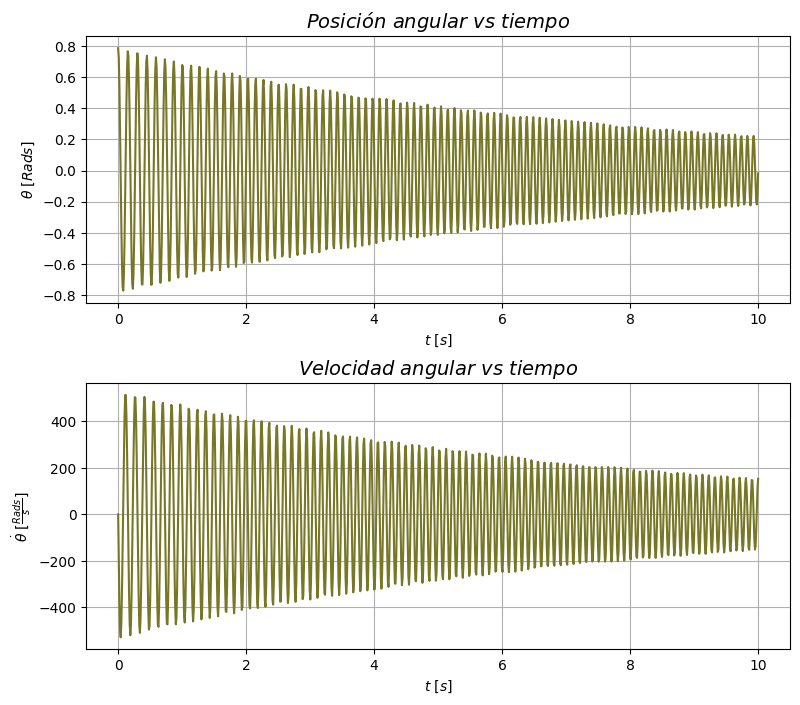

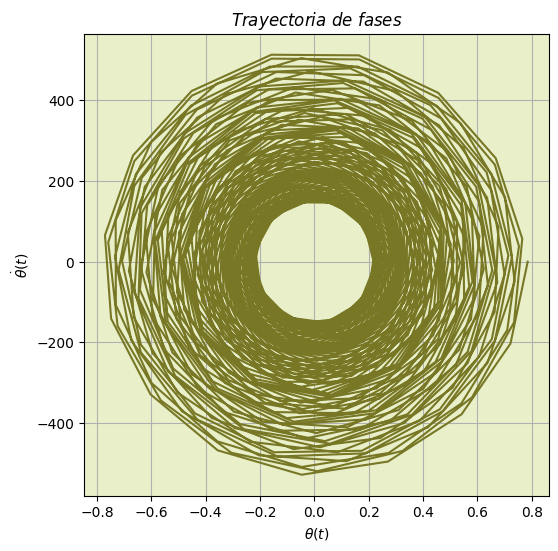

In [ ]:
#@title Solución de la ecuación diferencial que describe el efecto Josephson para $I>I_c$
# Sistema
IC=np.linspace(1e-6,1e-3,5)
def dU_dt(U,t,n,m,Ic):
  a=4.83e10
  I=IC[1]#corriente externa
  b=1e-3
  C=1e-3
  return [U[1],Ic/I -np.sin(U[0])*a*Ic - U[1]*(I/C)]


U0 =np.radians( [45,0])
# Intervalo
m=U0[0]
ic=1e-5

t = np.linspace(0,10, 1000)
sol=odeint(dU_dt,U0,t,args=(n,m,ic))

plt.subplots_adjust(bottom=.1,top=2.1,left=0.1,right=1.2,hspace=.3)
#-----------------Theta vs t-----------------------------------------
plt.subplot(3,1,1)

plt.plot(t,sol[:,0],'-',color='#777726')
plt.title(r'$\theta \,\,[Rads]$');
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\theta \,\,[Rads]$');
plt.title('$Posición \,\,angular \,\,vs\,\, tiempo$',size=14);
#plt.ylim(bottom=1)
plt.grid();

#-----------------dTheta_dt vs t-----------------------------------------
plt.subplot(3,1,2)

plt.plot(t,sol[:,1],'-',color='#777726')
plt.xlabel(r'$t\,\, [s]$');
plt.ylabel(r'$\dot{\theta} \,\,[\frac{Rads}{s}]$');
plt.title('$Velocidad \,\,angular\,\, vs\,\,tiempo$',size=14);
plt.grid();


figure, axes  =  plt.subplots(nrows = 1, ncols = 1,figsize = (6,6))  # big fig
figure.set_facecolor("#e9f0c9")
figure.patch.set_alpha(0.0)
axes.set_facecolor("#e9f0c9")


## axes.plot(U[1],U[2],'.')
axes.plot(sol[:,0],sol[:,1],color='#777726')
axes.grid()
axes.set_title(r'$Trayectoria {\ }de{\ }fases$')
axes.set_xlabel(r'$\theta(t)$')
axes.set_ylabel(r'$\dot{\theta}(t)$')

plt.show()



--------------------------------------------------------

<font size=5 color='k' >
<b>Análisis de la solución</b>
</font>

By analyzing the graphs representing the solution to the differential equation describing the phase variation in a Josephson junction, different behaviors can be observed depending on the current applied to the junction relative to the critical current, $I_c$.

When the external current $I$ is less than the critical current $I < I_c$, the current at the junction exhibits an oscillatory pattern similar to the oscillations observed in a simple pendulum. However, there is a fundamental difference: in the classical pendulum system, these oscillations manifest rapidly, while in the Josephson junction, a considerable amount of time is required before they become perceptible.

On the other hand, when the external current $I$ exceeds the critical current $I > I_c$, the Josephson junction exhibits oscillations resembling those of a damped and forced pendulum. However, unlike the classical oscillator, in the Josephson junction, these oscillations have a much higher frequency and require less time for their amplitude to decrease and eventually approach zero.

Regarding the phase-space trajectories, in the case of the simple pendulum, periodic behavior is expected, which is reflected in the circular representation of the graph. This pattern resembles the phase path of the Josephson junction when $I < I_c$.

On the other hand, in the case of the damped forced pendulum, the system does not exhibit periodic motion. After completing a full cycle, the representation of its phase-space trajectory does not form a closed curve, and the length of the radius of curvature gradually decreases, suggesting a decrease in the amplitude of the motion over time. This same characteristic is observed in the phase path of the Josephson junction when $I > I_c$.

--------------------------------------------------------

<font size=5 color='k' >
<b>Conclusionss</b>
</font>

Although it is a quantum system, the Josephson junction, under certain conditions, can behave analogously to a classical oscillator. This analogy can be useful as a reference for measuring some physical variables. In this case, the classical oscillator was helpful in providing an idea of ​​the oscillation frequencies.

The analogies between the parameters of the 1D nonlinear oscillator and the Josephson junction are:

Angle $\theta$ $\rightarrow$ Phase difference $\phi$

Angular velocity $\dot\theta$ $\rightarrow$ Voltage $\frac {\hbar}{2e} \phi$

Mass $m$ $\rightarrow$ Capacitance $c$

External force $\Gamma$ $\rightarrow$ External current $I$

Damming constant $2\lambda $$\rightarrow$ Conductance $\frac {1}{R}$

From the analogy between the pendulum and the Josephson junction, we have that the horizontal displacement of the pendulum corresponds to the tunneling current through the junction given by equation (1).


--------------------------------------------------------

<font size=5 color='k' >
<b>Referencias</b>
</font>

--------------------------------------------------------
**[1]** Colaboradores de Wikipedia. (2023). Efecto Josephson. Wikipedia, la enciclopedia libre. https://es.wikipedia.org/wiki/Efecto_Josephson

**[2]** Montealegre Cárdenas, E. (2008). Los Sistemas Dinámicos Relacionados con el Efecto Josephson. Universidad EAFIT, 113 páginas.

**[3]** Sandino Hernández, A. F., & Del Río Correa, J. L. (2023). La unión Josephson vista como un sistema dinámico. Departamento de Física, UAM Iztapalapa, México D.F., México.

**[4]** Landau, Lev Davidovich, and E. M. Lifshitz. Física teórica. Mecánica. Vol. 1. Reverte, 1970.